<a href="https://colab.research.google.com/github/elzbietapiechota/regresja_w_praktyce/blob/main/Regresja_w_praktyce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regresja Liniowa

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Wczytanie zbioru danych
bike_data_raw = pd.read_csv('daily-bike-share.csv')

# Przekształcenie typu danych
bike_data_raw['dteday'] = pd.to_datetime(bike_data_raw['dteday'])

# Przygotowanie przydatnych cech
bike_data = bike_data_raw.copy()
bike_data.drop(['instant', 'dteday', 'yr'], axis=1, inplace=True)

numeric_features = ['temp', 'atemp', 'hum', 'windspeed']
categorical_features = ['season','mnth','holiday','weekday','workingday','weathersit']
target = 'rentals'

# Przekształcenie cech temp/atemp
bike_data['difference_temp'] = (bike_data['atemp'] - bike_data['temp'])/bike_data['temp']
bike_data.drop(['atemp'], axis=1, inplace=True)
numeric_features = ['temp', 'difference_temp', 'hum', 'windspeed']

## Model jednej zmiennej

In [ ]:
# Określenie zmiennych dla modelu
X = bike_data[['temp']].copy()
y = bike_data[target].copy()

# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Stworzenie modelu i trening
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Generowanie prognoz
y_predict_train = lr_model.predict(X_train)
y_predict_test = lr_model.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error
from math import sqrt

# Metryki dla modelu regresji liniowej
print(f'Train R^2: {r2_score(y_train, y_predict_train)}')
print(f'Test MAE: {mean_absolute_error(y_test, y_predict_test)}')
print(f'Test MAPE: {mean_absolute_percentage_error(y_test, y_predict_test)}')
print(f'Test MSE: {mean_squared_error(y_test, y_predict_test)}')
print(f'Test RMSE: {sqrt(mean_squared_error(y_test, y_predict_test))}')

Train R^2: 0.30617863454631344
Test MAE: 391.02879410802956
Test MAPE: 2.9864925318560496
Test MSE: 397066.9447179113
Test RMSE: 630.1324818781454


## Model wielu zmiennych

In [ ]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings('ignore')

# Określenie zmiennych dla modelu
X = bike_data[numeric_features+categorical_features].copy()
y = bike_data[target].copy()

# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Transformacja zmiennych numerycznych
numeric_transformer = Pipeline(steps=[
    ('logtransformer', PowerTransformer()),
    ('standardscaler', StandardScaler()),
    ('polynomialfeatures', PolynomialFeatures())])

# Transformacja zmiennych kategorycznych
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Integracja transformatorów
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)])

# Tworzenie końcowego Pipeline
final_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('regressor', ElasticNet())])

params = {'preprocessor__num__polynomialfeatures__degree': [1, 2, 3, 4, 5],
          'regressor__alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 0.0, 1.0, 10.0, 100.0],
          'regressor__l1_ratio': np.arange(0, 1.1, 0.1)}

cv = KFold(n_splits=5, shuffle=False)

final_polynomial_regression_gridsearch = GridSearchCV(final_pipeline,
                                                      params,
                                                      scoring='neg_mean_squared_error',
                                                      cv=cv)

final_polynomial_regression_gridsearch.fit(X_train, y_train)
print("\nNajlepsze hiperparametry:", final_polynomial_regression_gridsearch.best_params_, "\n")

final_polynomial_regression_model = final_polynomial_regression_gridsearch.best_estimator_
predictions = final_polynomial_regression_model.predict(X_test)


Najlepsze hiperparametry: {'preprocessor__num__polynomialfeatures__degree': 1, 'regressor__alpha': 0.1, 'regressor__l1_ratio': np.float64(0.4)} 



In [ ]:
print(f'R^2: {r2_score(y_test, predictions)}')
print(f'MAE: {mean_absolute_error(y_test, predictions)}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, predictions)}')
print(f'MSE: {mean_squared_error(y_test, predictions)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, predictions))}')

R^2: 0.5246818862090766
MAE: 348.58519355155653
MAPE: 0.8593319730028242
MSE: 234195.93113131993
RMSE: 483.9379414050111


# Wizualizacyjna ocena modelu i porównanie modeli

## Wykres reszt

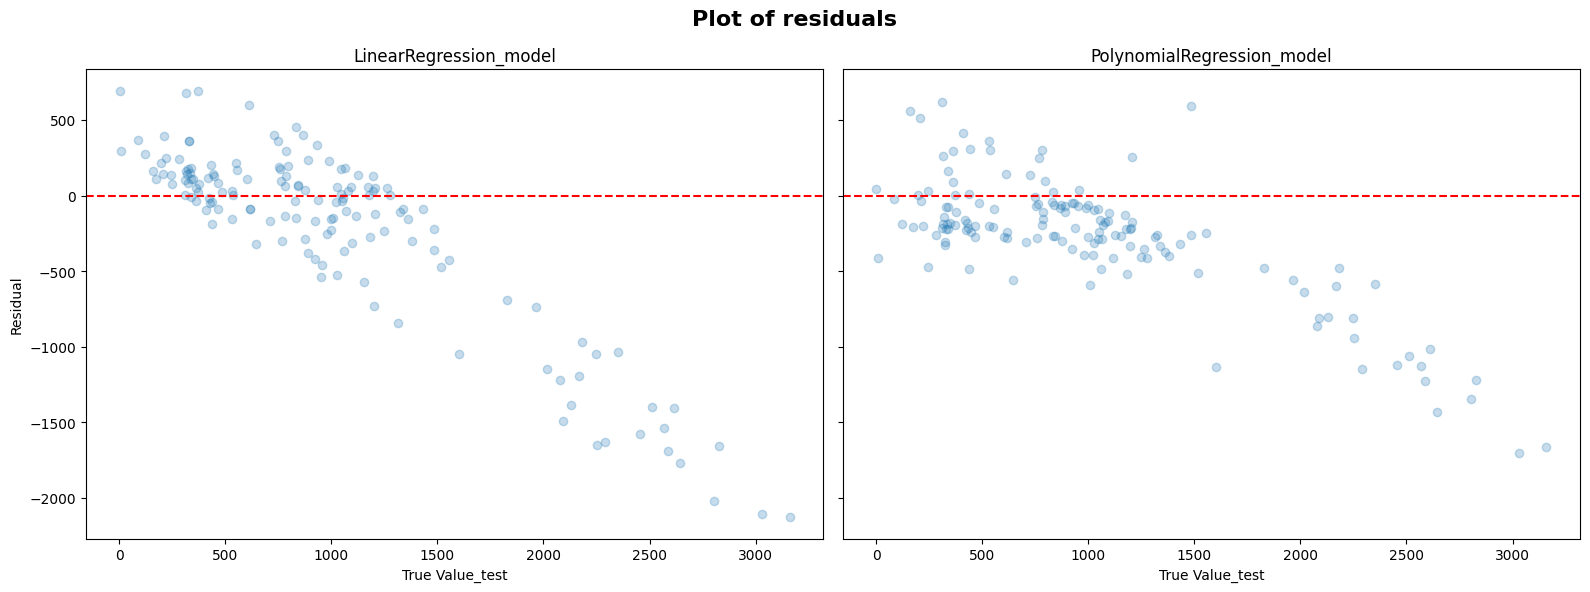

In [ ]:
import matplotlib.pyplot as plt

errors_first = y_predict_test - y_test
errors_final = predictions - y_test

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

ax1.scatter(x=y_test, y=errors_first, alpha=0.25)
ax1.axhline(0, color="r", linestyle="--")
ax1.set_xlabel('True Value_test')
ax1.set_ylabel('Residual')
ax1.set_title('LinearRegression_model')

ax2.scatter(x=y_test, y=errors_final, alpha=0.25)
ax2.axhline(0, color="r", linestyle="--")
ax2.set_xlabel('True Value_test')
ax2.set_title('PolynomialRegression_model')

plt.suptitle('Plot of residuals', size=16, weight='bold')
plt.tight_layout()
plt.show()

## Porównianie modeli

W obszarze niższych i średnich wartości najgęstsza chmura punktów skupia się  blisko zera, aczkolwiek leży poniżej tej linii, wskazując na tendencję do delikatnego niedoszacowania. W obszarze wysokich wartości chmura punktów podniosła się wyżej w porównaniu do pierwszego modelu, co dowodzi, że dodanie zmiennych i logarytmowanie poprawiło precyzję w momentach dużego natężenia ruchu. Punkty te nadal pozostają znacznie poniżej linii zero, co oznacza, że w dniach o najwyższej frekwencji model wciąż wykazuje tendencję do niedoszacowania końcowego wyniku.

## Histogram reszt

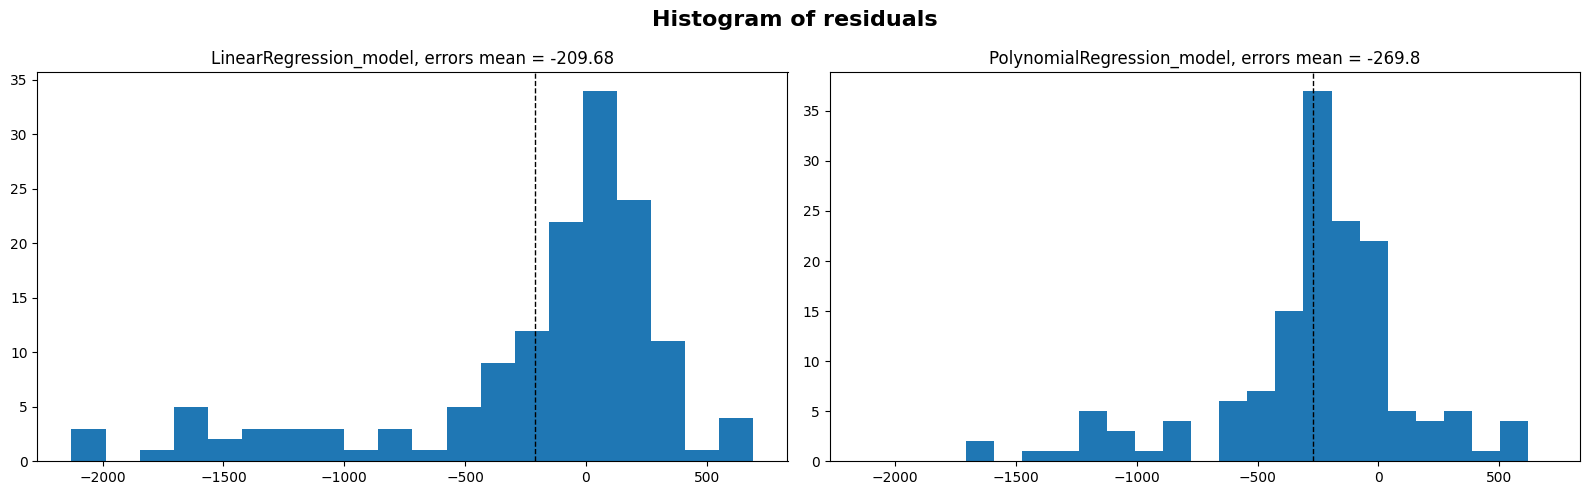

In [ ]:
# Tworzymy przestrzeń na dwa histogramy obok siebie
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), sharex=True)

# Histogram dla pierwszego modelu
ax1.hist(errors_first, bins=20)
ax1.axvline(errors_first.mean(), color='k', linestyle='dashed', linewidth=1)
ax1.set_title(f'LinearRegression_model, errors mean = {np.round(errors_first.mean(), 2)}')

# Histogram dla ostatecznego modelu
ax2.hist(errors_final, bins=20)
ax2.axvline(errors_final.mean(), color='k', linestyle='dashed', linewidth=1)
ax2.set_title(f'PolynomialRegression_model, errors mean = {np.round(errors_final.mean(), 2)}')

plt.suptitle('Histogram of residuals', size=16, weight='bold')
plt.tight_layout()
plt.show()

## Porównanie modeli

Histogram ostatniego modelu potwierdza obserwacje z wykresu reszt, czyli przesunięcie średniej błędu w stronę wartości ujemnych, co jest wynikiem systematycznego niedoszacowania prognoz. Zaletą ostatniego modelu jest wysoka koncentracja słupków wokół średniej. Rozkład jest węższy niż w modelu pierwszym, co oznacza, że mimo stałego, lekkiego niedoszacowania, ostatni model popełnia mniejsze błędy w poszczególnych dniach.